# 02 · U – Understanding the Data

Explorative Analyse von 2,06 Mio. Zielzeilen und räumlichem Kontext.

**Projekt:** MietCheck · Data Analytics & Big Data

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

COLORS = {"navy": "#14213D", "blue": "#2563EB", "teal": "#0F766E",
          "amber": "#F59E0B", "red": "#DC2626", "grey": "#64748B"}
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (9, 4.8), "axes.titleweight": "bold",
                     "axes.labelsize": 10, "figure.dpi": 110})

def load_json(relative_path):
    return json.loads((ROOT / relative_path).read_text(encoding="utf-8"))

print(f"Projektwurzel: {ROOT}")

Projektwurzel: C:\Users\nelek\Desktop\Big Data\MietCheck


## Daten laden

Für Diagramme wird eine deterministische Stichprobe gezogen; Kennzahlen und Modelle nutzen weiterhin die vollständige Tabelle beziehungsweise die dokumentierten großen Splits.

In [2]:
data_path = ROOT / "data/processed/model_table.parquet"
if not data_path.exists():
    raise FileNotFoundError("Zuerst: python scripts/download_data.py && python scripts/build_dataset.py")

columns = ["x_laea_m", "y_laea_m", "rent_eur_sqm", "building_after_1990",
           "dwelling_over_65sqm", "population", "avg_household_size",
           "ownership_rate_pct", "vacancy_rate_pct", "avg_dwelling_area_sqm",
           "dwelling_count", "target_uncertain"]
df = pd.read_parquet(data_path, columns=columns)
sample = df.sample(n=200_000, random_state=2026)
print(f"Vollbestand: {len(df):,} Zeilen · EDA-Stichprobe: {len(sample):,}")
display(sample["rent_eur_sqm"].describe(percentiles=[.01, .25, .5, .75, .99]).to_frame())

Vollbestand: 2,058,569 Zeilen · EDA-Stichprobe: 200,000


,rent_eur_sqm
count,200000.000000
mean,7.061794
std,2.487838
min,1.000000
1%,3.000000
25%,5.400000
50%,6.600000
75%,8.230000
99%,15.230000
max,49.450001


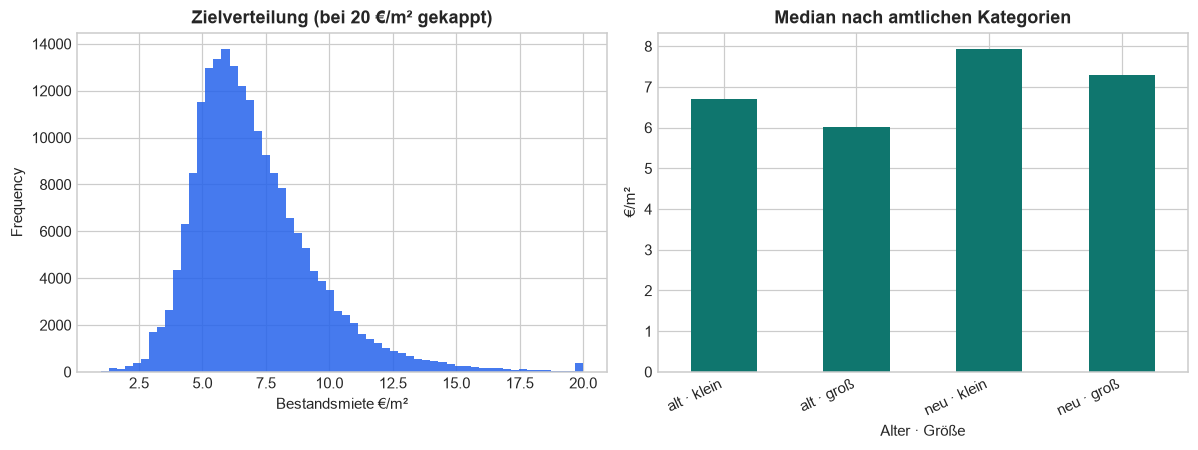

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
sample["rent_eur_sqm"].clip(upper=20).plot.hist(
    bins=60, ax=axes[0], color=COLORS["blue"], alpha=.85
)
axes[0].set(title="Zielverteilung (bei 20 €/m² gekappt)", xlabel="Bestandsmiete €/m²")

grouped = sample.groupby(["building_after_1990", "dwelling_over_65sqm"])["rent_eur_sqm"].median()
labels = ["alt · klein", "alt · groß", "neu · klein", "neu · groß"]
grouped.plot.bar(ax=axes[1], color=COLORS["teal"])
axes[1].set(title="Median nach amtlichen Kategorien", xlabel="Alter · Größe", ylabel="€/m²")
axes[1].set_xticklabels(labels, rotation=25, ha="right")
plt.tight_layout(); plt.show()

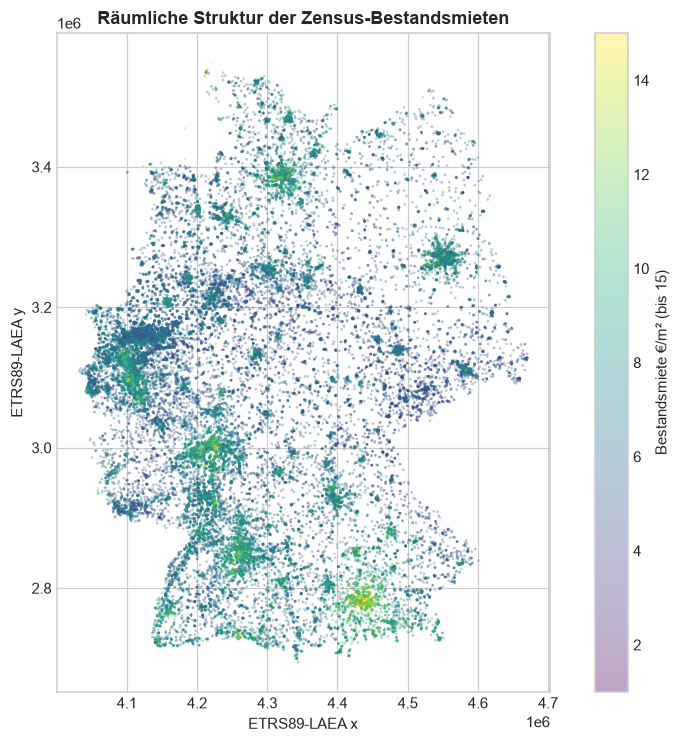

In [4]:
plot_sample = sample.sample(n=50_000, random_state=2026)
fig, ax = plt.subplots(figsize=(8.5, 7))
points = ax.scatter(plot_sample["x_laea_m"], plot_sample["y_laea_m"],
                    c=plot_sample["rent_eur_sqm"].clip(upper=15), s=3,
                    cmap="viridis", alpha=.35, linewidths=0)
fig.colorbar(points, ax=ax, label="Bestandsmiete €/m² (bis 15)")
ax.set(title="Räumliche Struktur der Zensus-Bestandsmieten",
       xlabel="ETRS89-LAEA x", ylabel="ETRS89-LAEA y")
ax.set_aspect("equal"); plt.tight_layout(); plt.show()

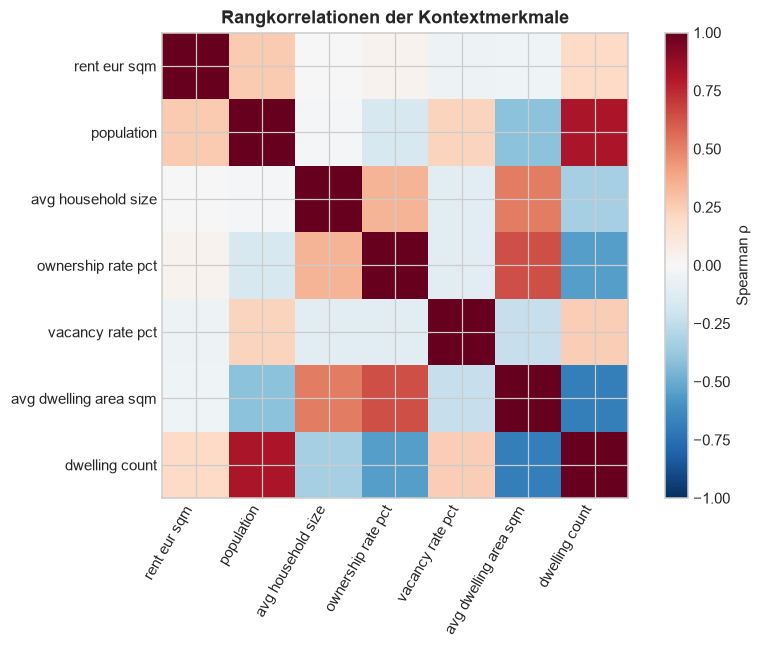

Zielunsicherheit: 11.5%


In [5]:
numeric = ["rent_eur_sqm", "population", "avg_household_size",
           "ownership_rate_pct", "vacancy_rate_pct", "avg_dwelling_area_sqm",
           "dwelling_count"]
corr = sample[numeric].corr(method="spearman")
fig, ax = plt.subplots(figsize=(8, 6))
image = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric)), [x.replace("_", " ") for x in numeric], rotation=60, ha="right")
ax.set_yticks(range(len(numeric)), [x.replace("_", " ") for x in numeric])
fig.colorbar(image, ax=ax, label="Spearman ρ")
ax.set_title("Rangkorrelationen der Kontextmerkmale")
plt.tight_layout(); plt.show()

print("Zielunsicherheit:", f"{df['target_uncertain'].mean():.1%}")

## EDA-Schlussfolgerungen

- Starke räumliche Struktur macht zufällige Zeilensplits ungeeignet.
- Neue Gebäude und kleinere Wohnungen weisen tendenziell höhere €/m²-Werte auf.
- Kontextmerkmale sind korreliert; Wichtigkeiten dürfen nicht kausal interpretiert werden.
- Die Zielverteilung besitzt einen langen rechten Rand. MAE und Median AE sind deshalb zentrale, robuste Metriken.
- Zensuswerte sind Gitterzellenaggregate, keine Einzelwohnungsbeobachtungen.

---

**Reproduzierbarkeit:** Die visualisierten Kennzahlen stammen aus versionierten JSON-/CSV-Artefakten. Die jeweils genannten Skripte erzeugen diese Artefakte aus den öffentlichen Rohdaten erneut. Relative Pfade funktionieren sowohl aus der Projektwurzel als auch aus `notebooks/`.